# GPU vs CPU PyTorch Benchmark (Apple Silicon / MPS)

This notebook verifies that PyTorch is **actually training on the GPU** (the Metal/MPS backend on Apple Silicon) and benchmarks it against the CPU, using *this project's real model* — the frozen-backbone ResNet18 from `scripts/model.py`.

It answers two questions:

1. Is the GPU (MPS) backend present, and do tensors / the model really run on it?
2. How much faster is GPU training than CPU — and how much extra does mixed precision (AMP) add?

> Run it from the `proj2/` folder: `uv run jupyter lab scripts/test-gpu/gpu_vs_cpu_benchmark.ipynb`, then **Run All**.

## 1. Setup & device detection

In [1]:
import sys, time, platform, contextlib
from pathlib import Path

# Make the proj2 root importable regardless of where Jupyter was launched.
_here = Path.cwd()
_root = next((p for p in [_here, *_here.parents] if (p / "scripts" / "model.py").exists()), _here)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
print("Project root:", _root)

import torch
import torch.nn as nn
from torch.optim import Adam

import scripts.config as config
from scripts.model import build_model

print("Python        :", platform.python_version())
print("Platform      :", platform.platform())
print("torch          :", torch.__version__)
print("MPS built      :", torch.backends.mps.is_built())
print("MPS available  :", torch.backends.mps.is_available())
print("CUDA available :", torch.cuda.is_available())
print("config.DEVICE  :", config.DEVICE, "| USE_AMP:", config.USE_AMP)

Project root: /Users/veto/Documents/git/kul-advanced-analytics/proj2


Python        : 3.13.9
Platform      : macOS-26.4-arm64-arm-64bit-Mach-O
torch          : 2.12.0
MPS built      : True
MPS available  : True
CUDA available : False
config.DEVICE  : mps | USE_AMP: True


## 2. Sanity check: do tensors really land on the GPU?

In [2]:
gpu_device = config.DEVICE if config.DEVICE.type != "cpu" else None
cpu_device = torch.device("cpu")

if gpu_device is None:
    print("No GPU backend detected - only CPU is available on this machine.")
else:
    t = torch.ones(3, device=gpu_device)
    out = (t * 2).sum()
    print("Tensor .device      :", t.device)
    print("Op result .device   :", out.device)
    print("Really on the GPU?  :", t.device.type == gpu_device.type)
    m = build_model(config.TOP_K).to(gpu_device).eval()
    with torch.no_grad():
        y = m(torch.randn(2, 3, 224, 224, device=gpu_device))
    print("Model output device :", y.device, "| shape:", tuple(y.shape))

Tensor .device      : mps:0
Op result .device   : mps:0
Really on the GPU?  : True


Model output device : mps:0 | shape: (2, 20)


## 3. The benchmark

We time a full training step (forward + loss + backward + optimizer step) on this project's model.

Two correctness details matter for honest GPU timing:
- **Synchronize**: MPS/CUDA dispatch work asynchronously, so we call `torch.mps.synchronize()` before stopping the timer - otherwise the GPU looks unrealistically fast.
- **Warm-up**: the first GPU call compiles Metal kernels, so we run a few untimed iterations first.

In [3]:
NUM_CLASSES = config.TOP_K
IMG_SHAPE = (3, 224, 224)

def _sync(device):
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()

def benchmark(device, iters=10, warmup=3, batch_size=32, use_amp=False, train=True):
    torch.manual_seed(0)
    model = build_model(NUM_CLASSES).to(device)
    model.train() if train else model.eval()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

    x = torch.randn(batch_size, *IMG_SHAPE, device=device)
    y = (torch.rand(batch_size, NUM_CLASSES, device=device) > 0.5).float()
    amp_on = use_amp and device.type in ("cuda", "mps")

    def step():
        optimizer.zero_grad(set_to_none=True)
        grad_ctx = contextlib.nullcontext() if train else torch.no_grad()
        with grad_ctx:
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=amp_on):
                loss = criterion(model(x), y)
            if train:
                loss.backward()
                optimizer.step()
        return loss

    for _ in range(warmup):
        step()
    _sync(device)

    t0 = time.perf_counter()
    for _ in range(iters):
        step()
    _sync(device)
    elapsed = time.perf_counter() - t0

    return {
        "device": device.type,
        "amp": amp_on,
        "batch": batch_size,
        "iters": iters,
        "sec_per_iter": elapsed / iters,
        "img_per_sec": (batch_size * iters) / elapsed,
    }

print("benchmark() ready")

benchmark() ready


## 4. Run the comparison

In [4]:
BATCH = 32
ITERS = 10
WARMUP = 3

results = []
print(f"Benchmarking a training step: batch={BATCH}, timed iters={ITERS} (+{WARMUP} warm-up)\n")

print("Running CPU (float32) ...")
results.append(benchmark(cpu_device, iters=ITERS, warmup=WARMUP, batch_size=BATCH, use_amp=False))

if gpu_device is not None:
    label = gpu_device.type.upper()
    print(f"Running {label} (float32) ...")
    results.append(benchmark(gpu_device, iters=ITERS, warmup=WARMUP, batch_size=BATCH, use_amp=False))
    print(f"Running {label} (mixed precision / AMP float16) ...")
    results.append(benchmark(gpu_device, iters=ITERS, warmup=WARMUP, batch_size=BATCH, use_amp=True))

print("\nDone.")

Benchmarking a training step: batch=32, timed iters=10 (+3 warm-up)

Running CPU (float32) ...


Running MPS (float32) ...


Running MPS (mixed precision / AMP float16) ...



Done.


## 5. Results

In [5]:
import pandas as pd

df = pd.DataFrame(results)
df["label"] = df.apply(lambda r: r["device"].upper() + (" + AMP" if r["amp"] else ""), axis=1)

cpu_ips = df.loc[df["device"] == "cpu", "img_per_sec"].iloc[0]
df["speedup_vs_cpu"] = df["img_per_sec"] / cpu_ips

show = df[["label", "sec_per_iter", "img_per_sec", "speedup_vs_cpu"]].copy()
show.columns = ["Config", "sec/iter", "images/sec", "speedup vs CPU"]
show["sec/iter"] = show["sec/iter"].map(lambda v: f"{v:.4f}")
show["images/sec"] = show["images/sec"].map(lambda v: f"{v:.1f}")
show["speedup vs CPU"] = show["speedup vs CPU"].map(lambda v: f"{v:.2f}x")
print(show.to_string(index=False))

   Config sec/iter images/sec speedup vs CPU
      CPU   0.3453       92.7          1.00x
      MPS   0.0215     1487.6         16.05x
MPS + AMP   0.0184     1743.5         18.81x


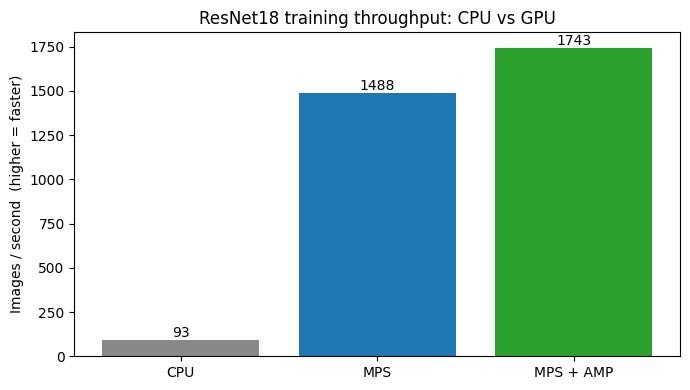

In [6]:
import matplotlib.pyplot as plt

colors = ["#888888", "#1f77b4", "#2ca02c"][:len(df)]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(df["label"], df["img_per_sec"], color=colors)
ax.set_ylabel("Images / second  (higher = faster)")
ax.set_title("ResNet18 training throughput: CPU vs GPU")
for rect, v in zip(bars, df["img_per_sec"]):
    ax.text(rect.get_x() + rect.get_width() / 2, v, f"{v:.0f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 6. Verdict

In [7]:
gpu_rows = df[df["device"] != "cpu"]
if gpu_rows.empty:
    print("VERDICT: This machine exposes no GPU backend to PyTorch - training runs on CPU only.")
else:
    best = gpu_rows.loc[gpu_rows["img_per_sec"].idxmax()]
    tag = best["device"].upper() + (" + AMP" if best["amp"] else "")
    print("VERDICT")
    print("-------")
    print(f"PyTorch IS using the GPU backend: '{best['device']}'.")
    print(f"The project trains on config.DEVICE = {config.DEVICE}.")
    print(f"Fastest config : {tag}")
    print(f"Speedup        : {best['speedup_vs_cpu']:.1f}x faster than CPU")
    print(f"Throughput     : {best['img_per_sec']:.0f} img/s (GPU) vs {cpu_ips:.0f} img/s (CPU)")

VERDICT
-------
PyTorch IS using the GPU backend: 'mps'.
The project trains on config.DEVICE = mps.
Fastest config : MPS + AMP
Speedup        : 18.8x faster than CPU
Throughput     : 1743 img/s (GPU) vs 93 img/s (CPU)
